In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv("HEART_DISEASE_PREDICT.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print(df.shape)


(1328, 14)


In [5]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [6]:
df.rename(columns={
    'age': 'Age',
    'sex': 'Gender',
    'cp': 'Chest Pain Type',
    'trestbps': 'Resting Blood Pressure',
    'chol': 'Cholesterol',
    'fbs': 'Fasting Blood Sugar',
    'restecg': 'Resting ECG',
    'thalach': 'Maximum Heart Rate',
    'exang': 'Exercise Induced Angina',
    'oldpeak': 'ST Depression',
    'slope': 'ST Slope',
    'ca': 'Major Vessels',
    'thal': 'Thalassemia Type',
    'target': 'Heart Disease'
}, inplace=True)

print(df.columns)

Index(['Age', 'Gender', 'Chest Pain Type', 'Resting Blood Pressure',
       'Cholesterol', 'Fasting Blood Sugar', 'Resting ECG',
       'Maximum Heart Rate', 'Exercise Induced Angina', 'ST Depression',
       'ST Slope', 'Major Vessels', 'Thalassemia Type', 'Heart Disease'],
      dtype='object')


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      1328 non-null   int64  
 1   Gender                   1328 non-null   int64  
 2   Chest Pain Type          1328 non-null   int64  
 3   Resting Blood Pressure   1328 non-null   int64  
 4   Cholesterol              1328 non-null   int64  
 5   Fasting Blood Sugar      1328 non-null   int64  
 6   Resting ECG              1328 non-null   int64  
 7   Maximum Heart Rate       1328 non-null   int64  
 8   Exercise Induced Angina  1328 non-null   int64  
 9   ST Depression            1328 non-null   float64
 10  ST Slope                 1328 non-null   int64  
 11  Major Vessels            1328 non-null   int64  
 12  Thalassemia Type         1328 non-null   int64  
 13  Heart Disease            1328 non-null   int64  
dtypes: float64(1), int64(13)

In [8]:
print(df.describe())


               Age       Gender  Chest Pain Type  Resting Blood Pressure  \
count  1328.000000  1328.000000      1328.000000             1328.000000   
mean     54.418675     0.692771         0.948042              131.614458   
std       9.071150     0.461519         1.029854               17.514997   
min      29.000000     0.000000         0.000000               94.000000   
25%      48.000000     0.000000         0.000000              120.000000   
50%      56.000000     1.000000         1.000000              130.000000   
75%      61.000000     1.000000         2.000000              140.000000   
max      77.000000     1.000000         3.000000              200.000000   

       Cholesterol  Fasting Blood Sugar  Resting ECG  Maximum Heart Rate  \
count  1328.000000          1328.000000  1328.000000         1328.000000   
mean    246.060241             0.149096     0.529367          149.235693   
std      51.627522             0.356318     0.527220           22.975286   
min     126

In [9]:
print(df['Heart Disease'].value_counts())

Heart Disease
1    691
0    637
Name: count, dtype: int64


In [10]:
df.isnull().sum()

Age                        0
Gender                     0
Chest Pain Type            0
Resting Blood Pressure     0
Cholesterol                0
Fasting Blood Sugar        0
Resting ECG                0
Maximum Heart Rate         0
Exercise Induced Angina    0
ST Depression              0
ST Slope                   0
Major Vessels              0
Thalassemia Type           0
Heart Disease              0
dtype: int64

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

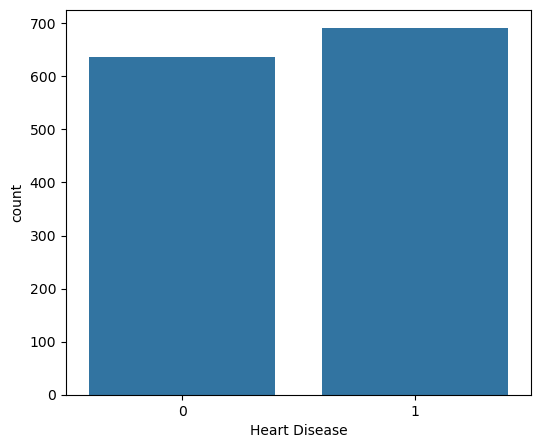

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Heart Disease'
)

plt.show()      

In [13]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

Age
[63 37 41 56 57 44 52 54 48 49 64 58 50 66 43 69 59 42 61 40 71 51 65 53
 46 45 39 47 62 34 35 29 55 60 67 68 74 76 70 38 77]
--------------------------------------------------
Gender
[1 0]
--------------------------------------------------
Chest Pain Type
[3 2 1 0]
--------------------------------------------------
Resting Blood Pressure
[145 130 120 140 172 150 110 135 160 105 125 142 155 104 138 128 108 134
 122 115 118 100 124  94 112 102 152 101 132 148 178 129 180 136 126 106
 156 170 146 117 200 165 174 192 144 123 154 114 164]
--------------------------------------------------
Cholesterol
[233 250 204 236 354 192 294 263 199 168 239 275 266 211 283 219 340 226
 247 234 243 302 212 175 417 197 198 177 273 213 304 232 269 360 308 245
 208 264 321 325 235 257 216 256 231 141 252 201 222 260 182 303 265 309
 186 203 183 220 209 258 227 261 221 205 240 318 298 564 277 214 248 255
 207 223 288 160 394 315 246 244 270 195 196 254 126 313 262 215 193 271
 268 267 210 295 306 178 24

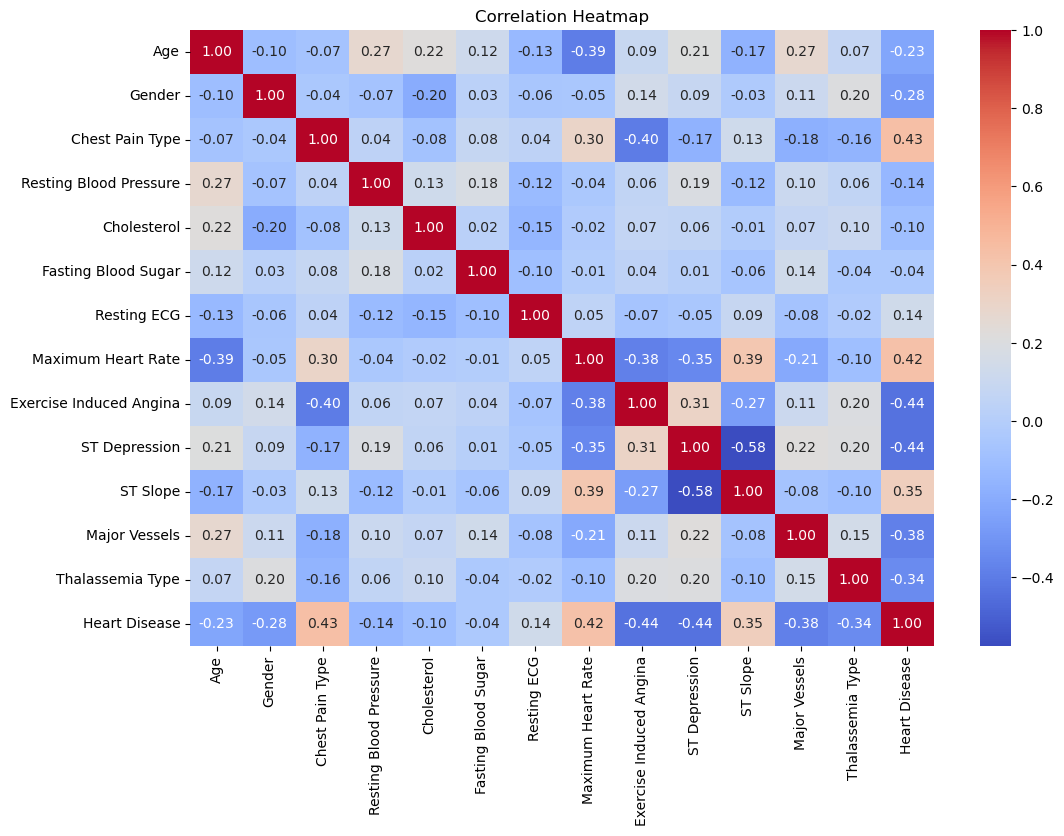

In [14]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [15]:
# Separate Features (X) and Target (y)

X = df.drop("Heart Disease", axis=1)

y = df["Heart Disease"]

In [16]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [17]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

Training Features : (929, 13)
Testing Features  : (399, 13)


In [18]:
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Target   : (929,)
Testing Target    : (399,)


In [19]:
# Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

results = []

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train,y_train)

y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test,y_pred_dt)
precision = precision_score(y_test,y_pred_dt)
recall = recall_score(y_test,y_pred_dt)
f1 = f1_score(y_test,y_pred_dt)
roc = roc_auc_score(y_test,y_prob_dt)

print("========== Decision Tree ==========")
print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 Score :",f1)
print("ROC AUC :",roc)

print(classification_report(y_test,y_pred_dt))
print(confusion_matrix(y_test,y_pred_dt))

results.append({
    "Model":"Decision Tree",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC AUC":roc
})

========== Decision Tree ==========
Accuracy : 0.9899749373433584
Precision : 1.0
Recall : 0.9807692307692307
F1 Score : 0.9902912621359223
ROC AUC : 0.9903846153846154
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       191
           1       1.00      0.98      0.99       208

    accuracy                           0.99       399
   macro avg       0.99      0.99      0.99       399
weighted avg       0.99      0.99      0.99       399

[[191   0]
 [  4 204]]


In [21]:
from sklearn.linear_model import LogisticRegression

# Create Model
lr_model = LogisticRegression(max_iter=1000)

# Train Model
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

# Probability Prediction
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

# Evaluation

accuracy = accuracy_score(y_test,y_pred_lr)
precision = precision_score(y_test,y_pred_lr)
recall = recall_score(y_test,y_pred_lr)
f1 = f1_score(y_test,y_pred_lr)
roc = roc_auc_score(y_test,y_prob_lr)

print("========== Logistic Regression ==========")
print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 Score :",f1)
print("ROC AUC :",roc)

print("\nClassification Report\n")
print(classification_report(y_test,y_pred_lr))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,y_pred_lr))

results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC AUC":roc
})

========== Logistic Regression ==========
Accuracy : 0.8395989974937343
Precision : 0.7950819672131147
Recall : 0.9326923076923077
F1 Score : 0.8584070796460177
ROC AUC : 0.9175392670157068

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.74      0.82       191
           1       0.80      0.93      0.86       208

    accuracy                           0.84       399
   macro avg       0.85      0.84      0.84       399
weighted avg       0.85      0.84      0.84       399


Confusion Matrix

[[141  50]
 [ 14 194]]


c:\Users\tamil\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test,y_pred_rf)
precision = precision_score(y_test,y_pred_rf)
recall = recall_score(y_test,y_pred_rf)
f1 = f1_score(y_test,y_pred_rf)
roc = roc_auc_score(y_test,y_prob_rf)

print("========== Random Forest ==========")
print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 Score :",f1)
print("ROC AUC :",roc)

print(classification_report(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

results.append({
    "Model":"Random Forest",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC AUC":roc
})

========== Random Forest ==========
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
ROC AUC : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       191
           1       1.00      1.00      1.00       208

    accuracy                           1.00       399
   macro avg       1.00      1.00      1.00       399
weighted avg       1.00      1.00      1.00       399

[[191   0]
 [  0 208]]


In [23]:
# Create DataFrame from model results

results_df = pd.DataFrame(results)

# Sort by Accuracy (Highest First)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

# Reset Index

results_df.reset_index(drop=True, inplace=True)

# Display Results

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.989975,1.000000,0.980769,0.990291,0.990385
2,Logistic Regression,0.839599,0.795082,0.932692,0.858407,0.917539


In [24]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")


['random_forest_model.pkl']

In [26]:
print(df.groupby("Heart Disease").mean())

                     Age    Gender  Chest Pain Type  Resting Blood Pressure  \
Heart Disease                                                                 
0              56.576138  0.827316         0.481947              134.169545   
1              52.429812  0.568741         1.377713              129.259045   

               Cholesterol  Fasting Blood Sugar  Resting ECG  \
Heart Disease                                                  
0               251.248038             0.163265     0.455259   
1               241.277858             0.136035     0.597685   

               Maximum Heart Rate  Exercise Induced Angina  ST Depression  \
Heart Disease                                                               
0                      139.124019                 0.549451       1.597017   
1                      158.557164                 0.136035       0.573082   

               ST Slope  Major Vessels  Thalassemia Type  
Heart Disease                                             

In [27]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print(model.classes_)
print(pred[:20])
print(y_test[:20].values)


[0 1]
[0 1 1 1 0 1 1 1 1 0 0 1 0 0 1 0 1 1 0 0]
[0 1 1 1 0 1 1 1 1 0 0 1 0 0 1 0 1 1 0 0]
